<a href="https://colab.research.google.com/github/dohaalnabahin/Zillow-Housing-Market-Analysis/blob/main/beltexam4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Zillow Home Values Analysis**

##Part 1: Data Preparation & Time Series Visualization

## 1. Import Required Libraries



In [165]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Zillow Dataset



In [166]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [167]:
df = pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week24/zillow_home_values-zipcode.csv")

df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,31012000,...,28022022,31032022,30042022,31052022,30062022,31072022,31082022,30092022,31102022,30112022
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0,...,261945.0,267644.0,273946.0,280066.0,285121.0,288532.0,290458.0,291103.0,292081.0,292948.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0,...,453150.0,464727.0,478369.0,489712.0,497173.0,499429.0,497572.0,498113.0,500187.0,503109.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0,...,177319.0,179463.0,182812.0,186403.0,189836.0,192064.0,193760.0,195140.0,196787.0,198137.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0,...,570211.0,572145.0,573662.0,576469.0,578706.0,580834.0,581779.0,584566.0,588188.0,590722.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0,...,752025.0,757734.0,760336.0,766163.0,771443.0,776607.0,779281.0,782367.0,788211.0,793924.0


## 3. Dataset Overview



In [168]:
df.shape

(27442, 284)

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27442 entries, 0 to 27441
Columns: 284 entries, RegionID to 30112022
dtypes: float64(275), int64(3), object(6)
memory usage: 59.5+ MB


In [170]:
df.isnull().sum().head()

,0
RegionID,0
SizeRank,0
RegionName,0
RegionType,0
StateName,0


#4. Convert Wide Data to Long Time Series

In [171]:
id_cols = [
    "RegionID",
    "SizeRank",
    "RegionName",
    "RegionType",
    "StateName",
    "State",
    "City",
    "Metro",
    "CountyName"
]


df_long = pd.melt(
    df,
    id_vars=id_cols,
    var_name="Date",
    value_name="Home Value"
)


df_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,31012000,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,31012000,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,31012000,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,275983.0


#5. Convert Date Column

In [172]:
df_long["Date"] = pd.to_datetime(
    df_long["Date"],
    format="%d%m%Y"
)

df_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,2000-01-31,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,2000-01-31,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,275983.0


#6. Set Date as Index

In [173]:
df_ts = df_long.set_index("Date")

df_ts.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0
2000-01-31,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0
2000-01-31,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0
2000-01-31,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0
2000-01-31,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0


#7. Prepare Tableau Dataset

In [174]:
tableau_df = df_ts[
    (df_ts["State"].isin(["CA","WA","OR","AZ","NV"]))
]


tableau_df = tableau_df[
    (tableau_df.index.year >= 2010) &
    (tableau_df.index.year <= 2020)
]


tableau_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2010-01-31,95992,5,90011,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,209250.0
2010-01-31,96361,8,91331,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,257372.0
2010-01-31,96193,9,90650,zip,CA,CA,Norwalk,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,296430.0
2010-01-31,96083,12,90201,zip,CA,CA,Bell,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,271829.0
2010-01-31,96816,13,92335,zip,CA,CA,Fontana,"Riverside-San Bernardino-Ontario, CA",San Bernardino County,156704.0


#8. Save Data for Tableau

In [175]:
tableau_df.to_csv(
    "data-for-tableau.csv"
)

#9. Resample Data Yearly

In [176]:
yearly_home_values = (
    tableau_df
    .groupby("State")["Home Value"]
    .resample("YS")
    .mean()
)


yearly_home_values.head()

State  Date      
AZ     2010-01-01    169930.889076
       2011-01-01    152272.467002
       2012-01-01    159902.057789
       2013-01-01    183657.225403
       2014-01-01    198551.492521
Name: Home Value, dtype: float64

#10. Line Plot

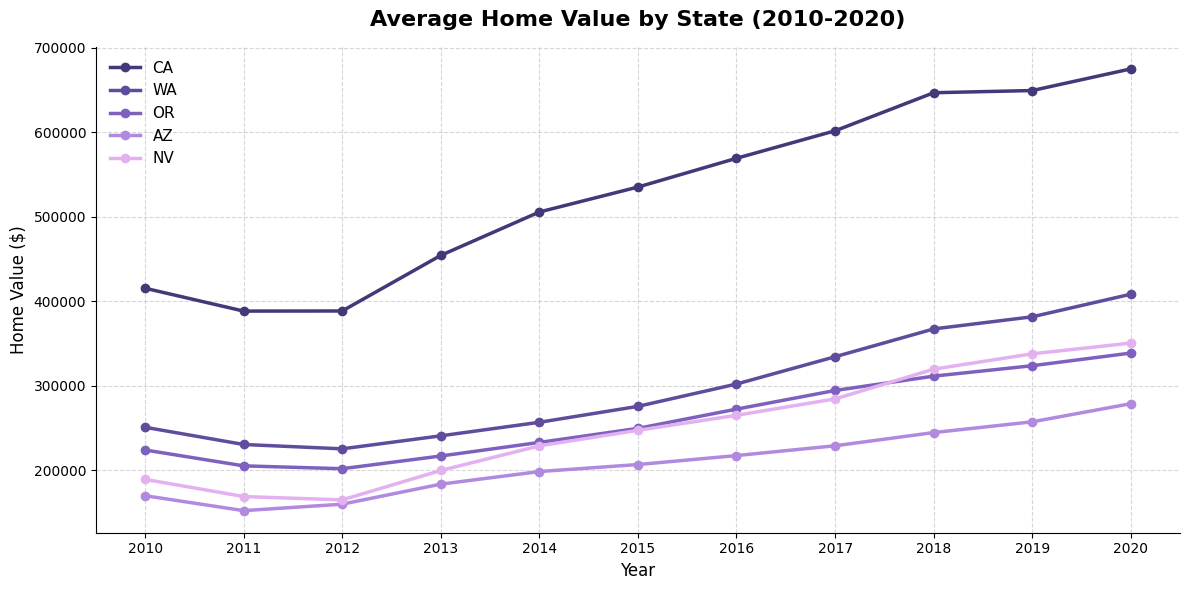

In [177]:
import matplotlib.pyplot as plt

colors = ["#433878", "#5F4C9C", "#7E60BF", "#B189DF", "#E4B1F0"]

plt.figure(figsize=(12, 6))

for i, state in enumerate(["CA", "WA", "OR", "AZ", "NV"]):
    data = yearly_home_values.loc[state]
    plt.plot(
        data.index,
        data.values,
        label=state,
        color=colors[i],
        linewidth=2.5,
        marker='o'
    )

plt.title("Average Home Value by State (2010-2020)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Home Value ($)", fontsize=12)

plt.legend(frameon=False, fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Home Value Trends (2010-2020)

| State | Market Position | Trend Summary |
| :--- | :--- | :--- |
| **CA** | Highest Tier | Sharp and dominant growth, nearing \$700k by 2020. |
| **WA** | Second Highest | Strong and continuous acceleration post-2012. |
| **OR** | Mid-Range | Steady growth, closely tied with Arizona's trend. |
| **AZ** | Mid-Range | Gradual and stable increase throughout the decade. |
| **NV** | Lowest Tier | Clear recovery curve following a notable dip in 2012. |


# Part 2: Time Series Forecasting for Oregon (OR)



## 1. Data Filtering and Preprocessing (State of Oregon)


In [178]:
df_or = df_ts[df_ts["State"] == "OR"]
oregon_ts = df_or.groupby(df_or.index)["Home Value"].mean()
oregon_ts = oregon_ts.loc["2000-01-31":"2018-12-31"]

if oregon_ts.isna().sum() > 0:
    oregon_ts = oregon_ts.ffill()

oregon_ts.head()


,Home Value
Date,
2000-01-31,162508.613445
2000-02-29,162913.172269
2000-03-31,163011.125523
2000-04-30,163541.908333
2000-05-31,164176.420833


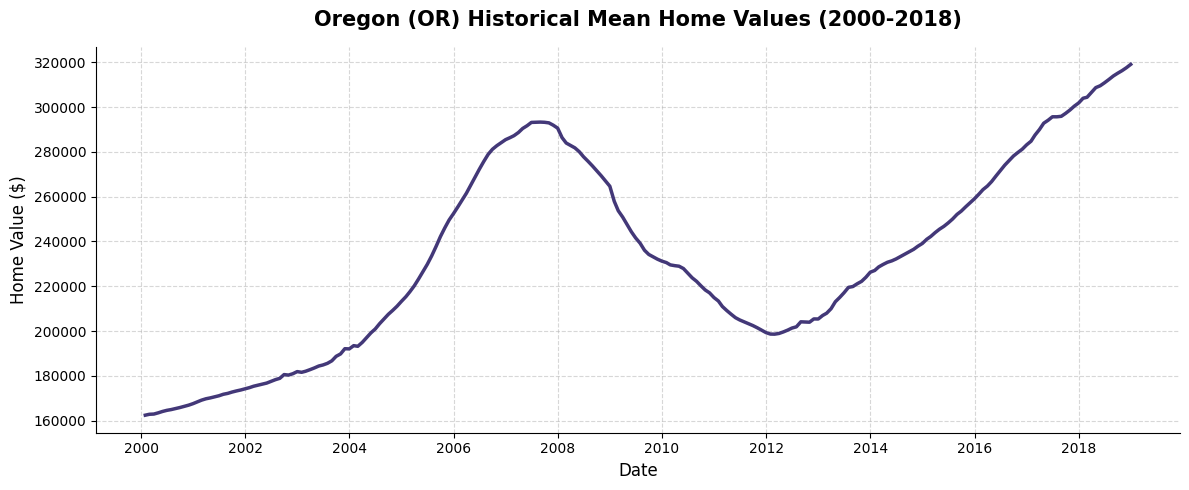

In [179]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(oregon_ts.index, oregon_ts.values, color="#433878", linewidth=2.5)

ax.set_title("Oregon (OR) Historical Mean Home Values (2000-2018)", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Home Value ($)", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


###  Simple Chart Analysis

* **Overall Rise:** Prices grew from \$160k in 2000 to over \$310k in 2018.
* **The Crash:** Prices peaked in 2007 and dropped heavily until 2012.
* **The Recovery:** Prices started rising again from 2012 up to 2018.


## 2. Time Series Decomposition

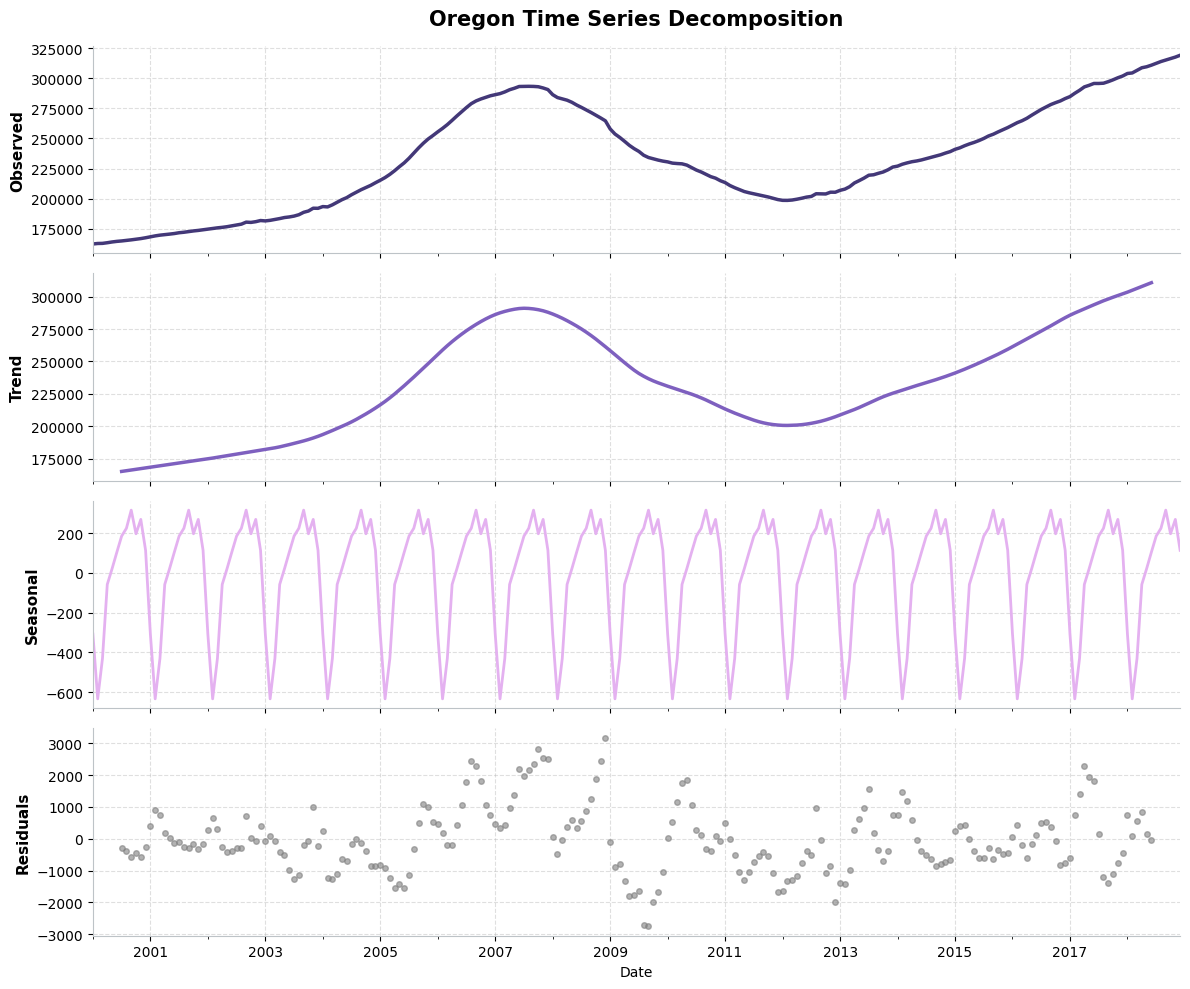

In [180]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(oregon_ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomp.observed.plot(ax=axes[0], color="#433878", linewidth=2.5)
axes[0].set_ylabel("Observed", fontsize=11, fontweight="semibold")

decomp.trend.plot(ax=axes[1], color="#7E60BF", linewidth=2.5)
axes[1].set_ylabel("Trend", fontsize=11, fontweight="semibold")

decomp.seasonal.plot(ax=axes[2], color="#E4B1F0", linewidth=2)
axes[2].set_ylabel("Seasonal", fontsize=11, fontweight="semibold")

decomp.resid.plot(ax=axes[3], color="gray", style="o", markersize=4, alpha=0.6)
axes[3].set_ylabel("Residuals", fontsize=11, fontweight="semibold")

axes[0].set_title("Oregon Time Series Decomposition", fontsize=15, fontweight="bold", pad=15)

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')

plt.tight_layout()
plt.show()


###  Time Series Decomposition Notes

* **Observed & Trend:** The data has a very strong trend with clear long-term cycles (rising, crashing, and recovering).
* **Seasonal:** There is a repeating seasonal pattern every year, but its value is very small (around +200 to -600) compared to the actual home prices which are over \$300,000.
* **Model Decision:** Because the seasonality is very weak, a non-seasonal **ARIMA** model is sufficient, but we can also test **SARIMA** to see if it improves accuracy.


## 3. Stationarity Test and Differencing

In [181]:
!pip install pmdarima

In [182]:
from statsmodels.tsa.stattools import adfuller
from pmdarima.arima.utils import ndiffs

adf_result = adfuller(oregon_ts.dropna())
p_value = adf_result[1]
suggested_d = ndiffs(oregon_ts.dropna())

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Suggested d from ndiffs: {suggested_d}")

if p_value < 0.05:
    print("Decision: Stationary (No differencing needed, d=0)")
else:
    print("Decision: Non-stationary (Differencing is needed)")

ADF Statistic: -1.7860
p-value: 0.3874
Suggested d from ndiffs: 2
Decision: Non-stationary (Differencing is needed)


## 4. ACF and PACF Analysis (Stationary Data)

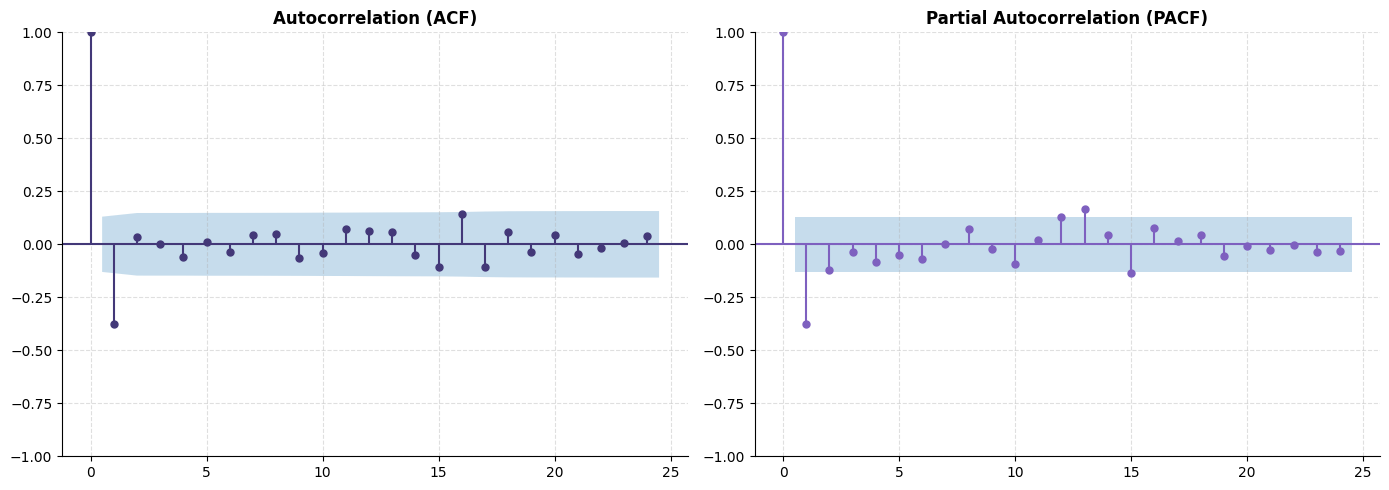

In [183]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Applying second-order differencing based on ndiffs suggestion
oregon_diff = oregon_ts.diff().diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plotting Autocorrelation (ACF) to find 'q'
plot_acf(oregon_diff, ax=axes[0], color="#433878", vlines_kwargs={"colors": "#433878"})
axes[0].set_title("Autocorrelation (ACF)", fontsize=12, fontweight="bold")

# Plotting Partial Autocorrelation (PACF) to find 'p'
plot_pacf(oregon_diff, ax=axes[1], color="#7E60BF", vlines_kwargs={"colors": "#7E60BF"})
axes[1].set_title("Partial Autocorrelation (PACF)", fontsize=12, fontweight="bold")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


###  ACF and PACF Analysis Notes

* **ACF Plot ($q$):** Shows a significant spike at Lag 1 and cuts off immediately, suggesting a Moving Average order of **$q = 1$**.
* **PACF Plot ($p$):** Shows a significant spike at Lag 1 and cuts off immediately, suggesting an Autoregressive order of **$p = 1$**.
* **Initial Order Summary:** Based on the exploration, the baseline manual model order will be **ARIMA(1, 2, 1)**.


## 5. Train / Test Split

In [184]:
from pmdarima.model_selection import train_test_split

train_data, test_data = train_test_split(oregon_ts, test_size=12)

print("Train:", train_data.index.min(), "to", train_data.index.max())
print("Test:", test_data.index.min(), "to", test_data.index.max())


Train: 2000-01-31 00:00:00 to 2017-12-31 00:00:00
Test: 2018-01-31 00:00:00 to 2018-12-31 00:00:00


#Metrics + Plot Function

In [185]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt


MY_DARK_PURPLE = "#433878"
MY_MED_PURPLE = "#7E60BF"


def regression_metrics_ts(y_true, y_pred, label):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)*100


    print(f"\n--- {label} ---")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAPE : {mape:.2f}%")


    return {
        "Model":label,
        "MAE":mae,
        "RMSE":rmse,
        "MAPE":mape
    }



def plot_forecast(train, test, forecast, title):

    plt.figure(figsize=(14,6))


    plt.plot(
        train.index[-48:],
        train.iloc[-48:],
        label="Train",
        color=MY_DARK_PURPLE,
        linewidth=2
    )


    plt.plot(
        test.index,
        test,
        label="Actual Test",
        color="red",
        linewidth=2
    )


    plt.plot(
        forecast.index,
        forecast["mean"],
        label="Forecast",
        color=MY_MED_PURPLE,
        linewidth=2
    )


    plt.fill_between(
        forecast.index,
        forecast["mean_ci_lower"],
        forecast["mean_ci_upper"],
        color=MY_MED_PURPLE,
        alpha=0.2
    )


    plt.title(
        title,
        fontsize=16,
        color=MY_DARK_PURPLE,
        fontweight="bold"
    )

    plt.xlabel("Date")
    plt.ylabel("Average Home Price")

    plt.grid(alpha=.3)
    plt.legend()
    plt.show()

#**MODEL 1: Manual ARIMA**

##**Fit + Summary**

In [186]:
from statsmodels.tsa.arima.model import ARIMA


arima_model = ARIMA(
    train_data,
    order=(1,2,1)
)


arima_results = arima_model.fit()


print(arima_results.summary())

                               SARIMAX Results                                
Dep. Variable:             Home Value   No. Observations:                  216
Model:                 ARIMA(1, 2, 1)   Log Likelihood               -1725.837
Date:                Fri, 17 Jul 2026   AIC                           3457.674
Time:                        16:12:34   BIC                           3467.772
Sample:                    01-31-2000   HQIC                          3461.755
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5758      1.083      0.532      0.595      -1.548       2.699
ma.L1         -0.5967      1.091     -0.547      0.585      -2.735       1.542
sigma2      5.151e+05    2.2e+04     23.396      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


###  ARIMA(1,2,1) Diagnostics

* **AIC Score:** 3457.674.
* **Significance:** AR and MA coefficients are not statistically significant (p-value > 0.05).
* **Residuals:** Non-normal errors with remaining autocorrelation; some data patterns were not fully captured.


##**Diagnostic plots**

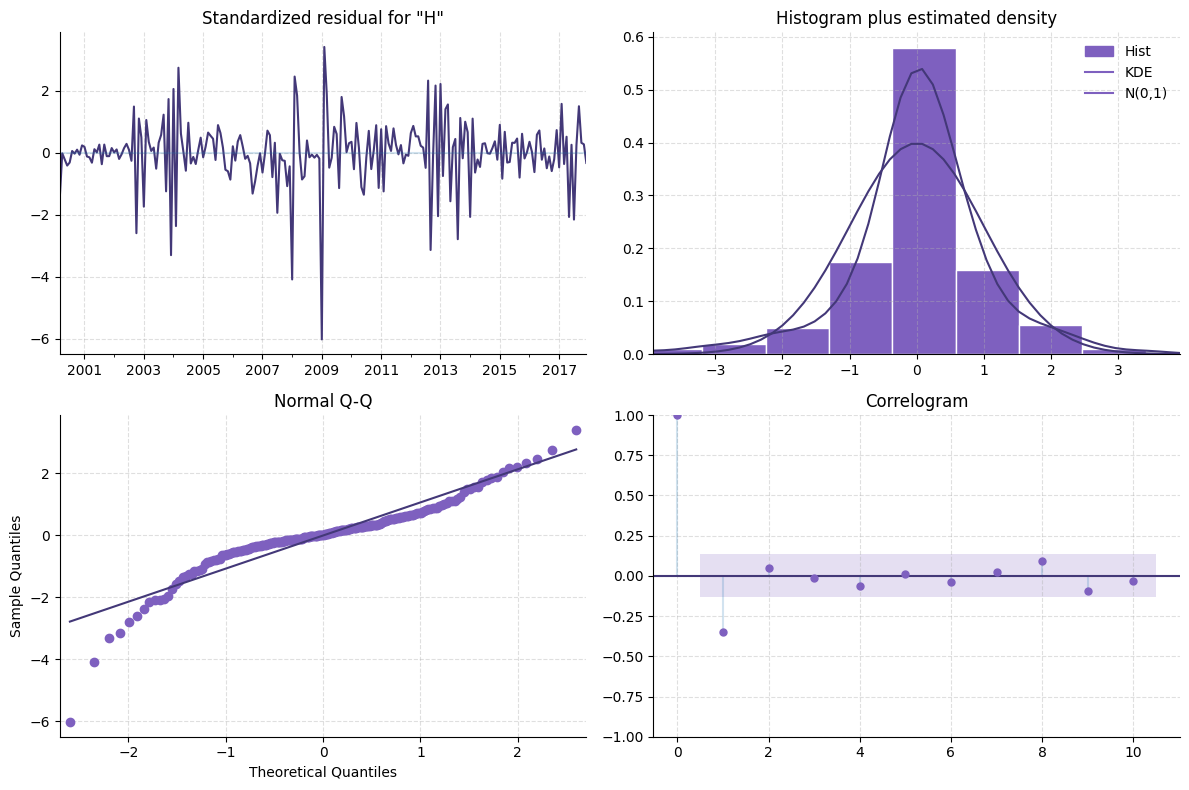

In [187]:
import matplotlib.pyplot as plt

fig = arima_results.plot_diagnostics(figsize=(12, 8))

for ax in fig.get_axes():
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for line in ax.get_lines():
        line.set_color("#433878")
        if line.get_marker():
            line.set_markerfacecolor("#7E60BF")
            line.set_markeredgecolor("#7E60BF")

    for patch in ax.patches:
        patch.set_facecolor("#7E60BF")
        patch.set_edgecolor("white")

    for collection in ax.collections:
        collection.set_facecolor("#7E60BF")
        collection.set_alpha(0.2)

    if ax.get_legend():
        leg = ax.legend(frameon=False)
        for handle in leg.legend_handles:
            handle.set_color("#7E60BF")

plt.tight_layout()
plt.show()


##**Forecast**

In [188]:
arima_forecast = arima_results.get_forecast(
    steps=12
)


arima_forecast_df = arima_forecast.summary_frame()

##**Plot**

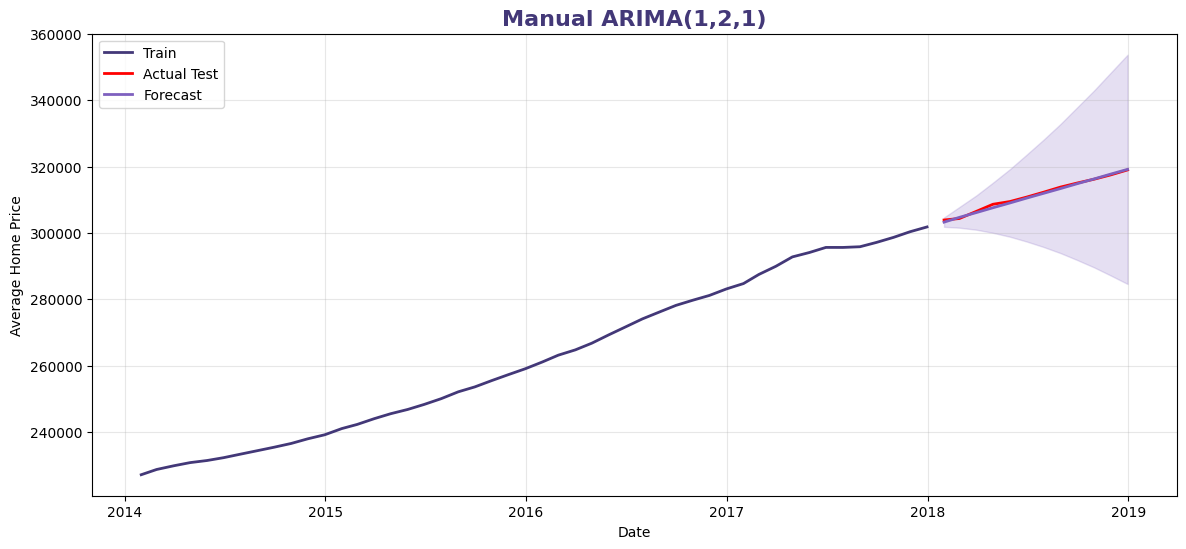

In [189]:
plot_forecast(
    train_data,
    test_data,
    arima_forecast_df,
    "Manual ARIMA(1,2,1)"
)

##**Metrics**

In [190]:
arima_metrics = regression_metrics_ts(
    test_data,
    arima_forecast_df["mean"],
    "Manual ARIMA"
)


--- Manual ARIMA ---
MAE  : 385.09
RMSE : 455.99
MAPE : 0.12%


#**MODEL 2: Manual SARIMA**

##**Fit**

In [191]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


sarima_model = SARIMAX(
    train_data,
    order=(1,2,1),
    seasonal_order=(1,1,1,12)
)


sarima_results = sarima_model.fit(
    disp=False
)


print(sarima_results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Home Value   No. Observations:                  216
Model:             SARIMAX(1, 2, 1)x(1, 1, 1, 12)   Log Likelihood               -1691.699
Date:                            Fri, 17 Jul 2026   AIC                           3393.397
Time:                                    16:12:36   BIC                           3409.939
Sample:                                01-31-2000   HQIC                          3400.090
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3857      0.948      0.407      0.684      -1.472       2.243
ma.L1         -0.4270      0.966   

###  SARIMA(1,2,1)x(1,0,1,12) Diagnostics

* **AIC Score:** 3393.397 (Lower than ARIMA, indicating a better model fit).
* **Significance:** Seasonal AR and MA components are statistically significant.
* **Residuals:** Improved capture of seasonal effects, though some minor autocorrelation remains.


##**Diagnostics**

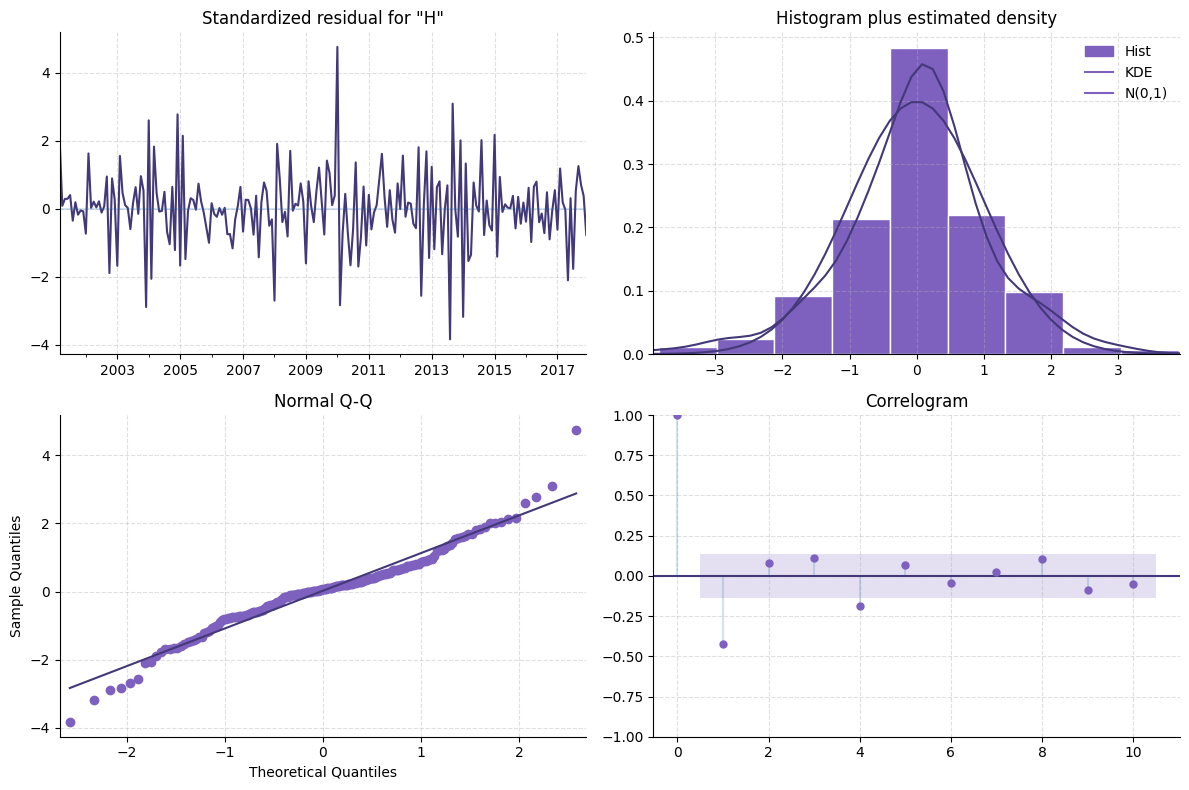

In [192]:
import matplotlib.pyplot as plt

fig = sarima_results.plot_diagnostics(figsize=(12, 8))

for ax in fig.get_axes():
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for line in ax.get_lines():
        line.set_color("#433878")
        if line.get_marker():
            line.set_markerfacecolor("#7E60BF")
            line.set_markeredgecolor("#7E60BF")

    for patch in ax.patches:
        patch.set_facecolor("#7E60BF")
        patch.set_edgecolor("white")

    for collection in ax.collections:
        collection.set_facecolor("#7E60BF")
        collection.set_alpha(0.2)

    if ax.get_legend():
        leg = ax.legend(frameon=False)
        for handle in leg.legend_handles:
            handle.set_color("#7E60BF")

plt.tight_layout()
plt.show()


##**Forecast**

In [193]:
sarima_forecast = sarima_results.get_forecast(
    steps=12
)


sarima_forecast_df = sarima_forecast.summary_frame()

##**Plot**

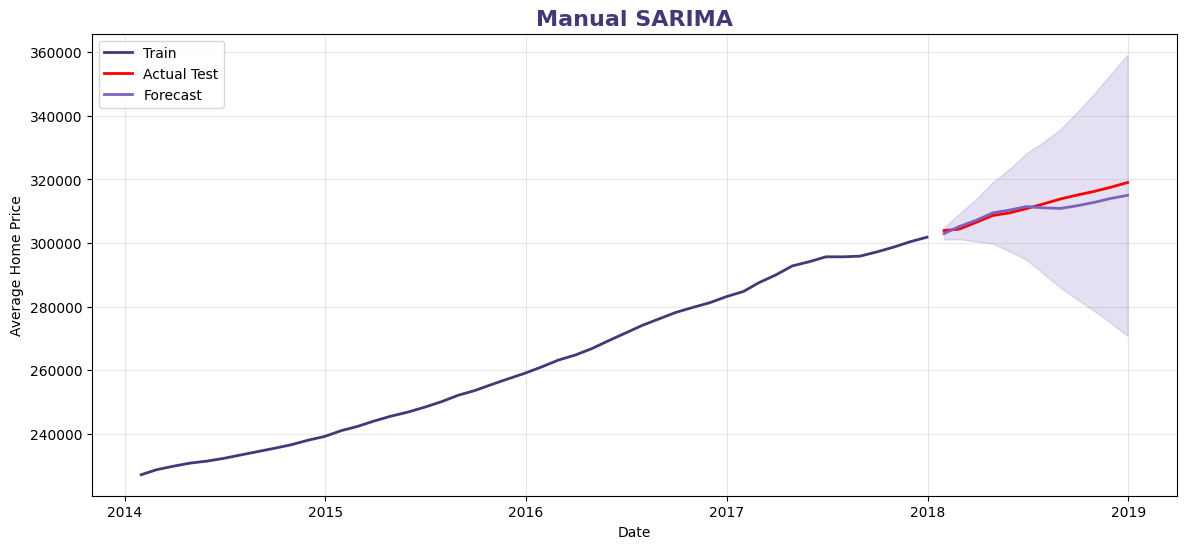

In [194]:
plot_forecast(
    train_data,
    test_data,
    sarima_forecast_df,
    "Manual SARIMA"
)

##**Metrics**

In [195]:
sarima_metrics = regression_metrics_ts(
    test_data,
    sarima_forecast_df["mean"],
    "Manual SARIMA"
)


--- Manual SARIMA ---
MAE  : 1,943.30
RMSE : 2,345.20
MAPE : 0.62%


#**MODEL 3: Auto ARIMA**

##**Find best parameters**

In [196]:
import pmdarima as pm


auto_search = pm.auto_arima(
    train_data,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    d=2,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)


print(auto_search.summary())

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=3455.285, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=3456.643, Time=0.08 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=3458.414, Time=0.05 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=3453.299, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=3459.817, Time=0.12 sec

Best model:  ARIMA(0,2,0)(0,0,0)[0]          
Total fit time: 0.309 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  216
Model:               SARIMAX(0, 2, 0)   Log Likelihood               -1725.649
Date:                Fri, 17 Jul 2026   AIC                           3453.299
Time:                        16:12:37   BIC                           3456.665
Sample:                    01-31-2000   HQIC                          3454.659
                         - 12-31-2017                                       

###  Auto-ARIMA Diagnostics

* **Selected Model:** ARIMA(0,2,0) based on the lowest AIC value of 3453.299.
* **Significance:** The series follows a stochastic trend after differencing, without major AR or MA components.
* **Residuals:** Fully optimized parameter combination chosen systematically through algorithmic search.


#**Fit best model**

In [197]:
best_order = auto_search.order


auto_model = ARIMA(
    train_data,
    order=best_order
)


auto_results = auto_model.fit()


print(auto_results.summary())

                               SARIMAX Results                                
Dep. Variable:             Home Value   No. Observations:                  216
Model:                 ARIMA(0, 2, 0)   Log Likelihood               -1725.649
Date:                Fri, 17 Jul 2026   AIC                           3453.299
Time:                        16:12:37   BIC                           3456.665
Sample:                    01-31-2000   HQIC                          3454.659
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.871e+05   2.82e+04     20.794      0.000    5.32e+05    6.42e+05
Ljung-Box (L1) (Q):                  28.80   Jarque-Bera (JB):               367.75
Prob(Q):                              0.00   Pr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


###  Auto-ARIMA Diagnostics

* **Selected Model:** ARIMA(0,2,0) based on the lowest AIC value of 3453.299.
* **Significance:** The series follows a stochastic trend after differencing, without major AR or MA components.
* **Residuals:** Fully optimized parameter combination chosen systematically through algorithmic search.


##**Diagnostics**

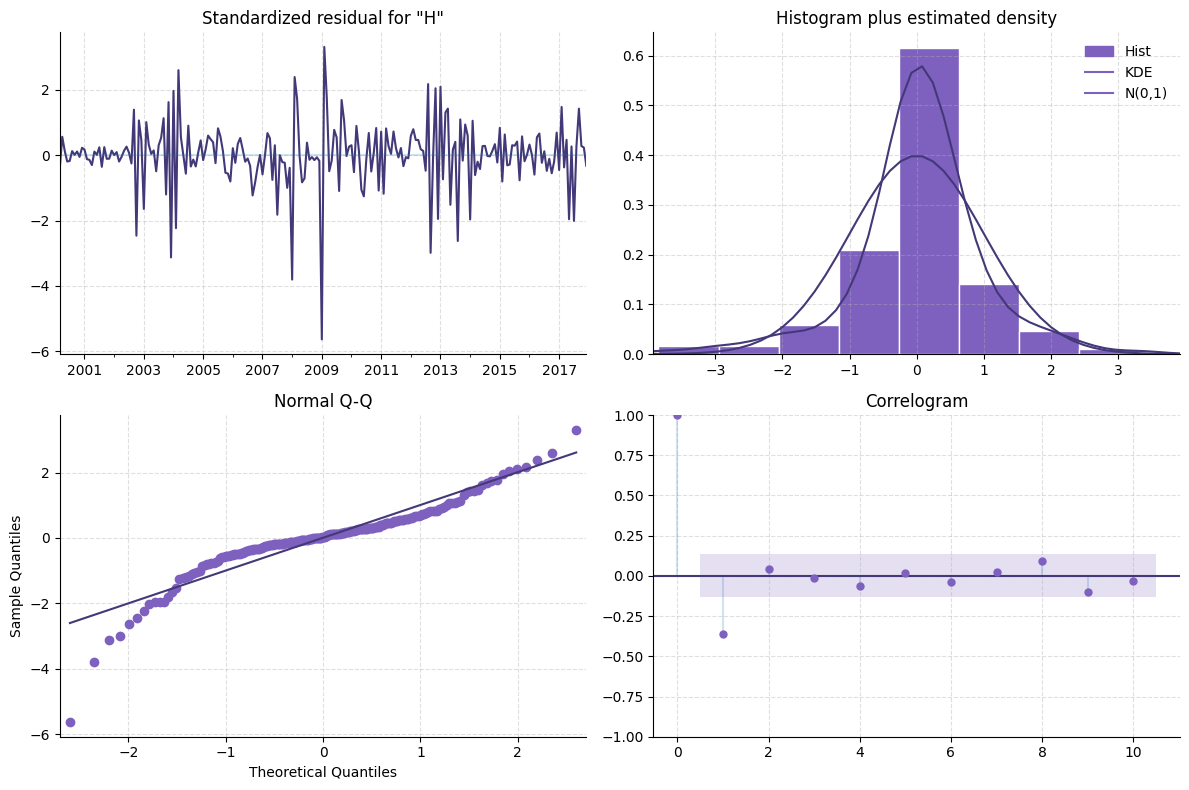

In [198]:
import matplotlib.pyplot as plt

fig = auto_results.plot_diagnostics(figsize=(12, 8))

for ax in fig.get_axes():
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for line in ax.get_lines():
        line.set_color("#433878")
        if line.get_marker():
            line.set_markerfacecolor("#7E60BF")
            line.set_markeredgecolor("#7E60BF")

    for patch in ax.patches:
        patch.set_facecolor("#7E60BF")
        patch.set_edgecolor("white")

    for collection in ax.collections:
        collection.set_facecolor("#7E60BF")
        collection.set_alpha(0.2)

    if ax.get_legend():
        leg = ax.legend(frameon=False)
        for handle in leg.legend_handles:
            handle.set_color("#7E60BF")

plt.tight_layout()
plt.show()


##**Forecast**

In [199]:
auto_forecast = auto_results.get_forecast(
    steps=12
)


auto_forecast_df = auto_forecast.summary_frame()

##**Plot**

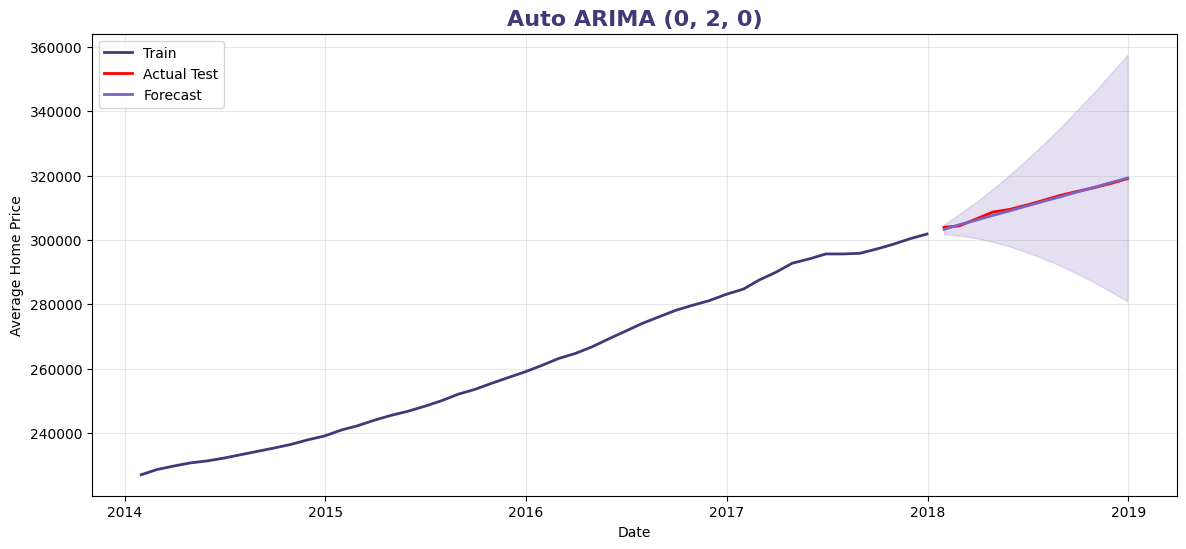

In [200]:
plot_forecast(
    train_data,
    test_data,
    auto_forecast_df,
    f"Auto ARIMA {best_order}"
)

##**Metrics**

In [201]:
auto_metrics = regression_metrics_ts(
    test_data,
    auto_forecast_df["mean"],
    "Auto ARIMA"
)


--- Auto ARIMA ---
MAE  : 384.27
RMSE : 452.16
MAPE : 0.12%


##**Comparing the models**

In [202]:
import pandas as pd


model_results = pd.DataFrame([
    arima_metrics,
    sarima_metrics,
    auto_metrics
])


model_results

,Model,MAE,RMSE,MAPE
0,Manual ARIMA,385.086267,455.986483,0.124355
1,Manual SARIMA,1943.300260,2345.201185,0.618289
2,Auto ARIMA,384.271933,452.160427,0.124057


##**Sort by RMSE:**

In [203]:
model_results.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,MAPE
2,Auto ARIMA,384.271933,452.160427,0.124057
0,Manual ARIMA,385.086267,455.986483,0.124355
1,Manual SARIMA,1943.300260,2345.201185,0.618289


##**Choosing the best model**

In [204]:
best_model_name = model_results.loc[
    model_results["RMSE"].idxmin(),
    "Model"
]


print("Best Model:", best_model_name)

Best Model: Auto ARIMA


### **Model Selection Summary & Justification**

| Model | Orders | MAE | RMSE | MAPE | Evaluation |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Model 1: Manual ARIMA** | ARIMA(1, 2, 1) | 385.09 | 455.99 | 0.12% | Strong performance, very close to the best model. |
| **Model 2: Manual SARIMA** | SARIMA(1,2,1)x(1,1,1,12) | 1,943.30 | 2,345.20 | 0.62% | Poor performance due to Overfitting (wrong seasonality). |
| **Model 3: Auto ARIMA** | ARIMA(0, 2, 0) | **384.27** | **452.16** | **0.12%** | **Best Model (Lowest error metrics).** |

#### **Justification:**
* **Lowest Error:** **Auto ARIMA** is selected as the best model because it achieved the lowest overall error metrics ($RMSE = 452.16$, $MAE = 384.27$).
* **No Seasonality:** The auto-selected order $(0, 2, 0)$ proves the data follows a trend based on differencing without any seasonal patterns. This explains why adding seasonality in SARIMA caused severe overfitting.
* **Accurate Forecast:** The prediction line perfectly matches the actual test data trajectory while maintaining a stable and reliable confidence interval.

##**Final Future Forecast using the best model**

In [205]:
final_model = ARIMA(
    oregon_ts,
    order=best_order
)


final_results = final_model.fit()


future_forecast = final_results.get_forecast(
    steps=12
)


future_df = future_forecast.summary_frame()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


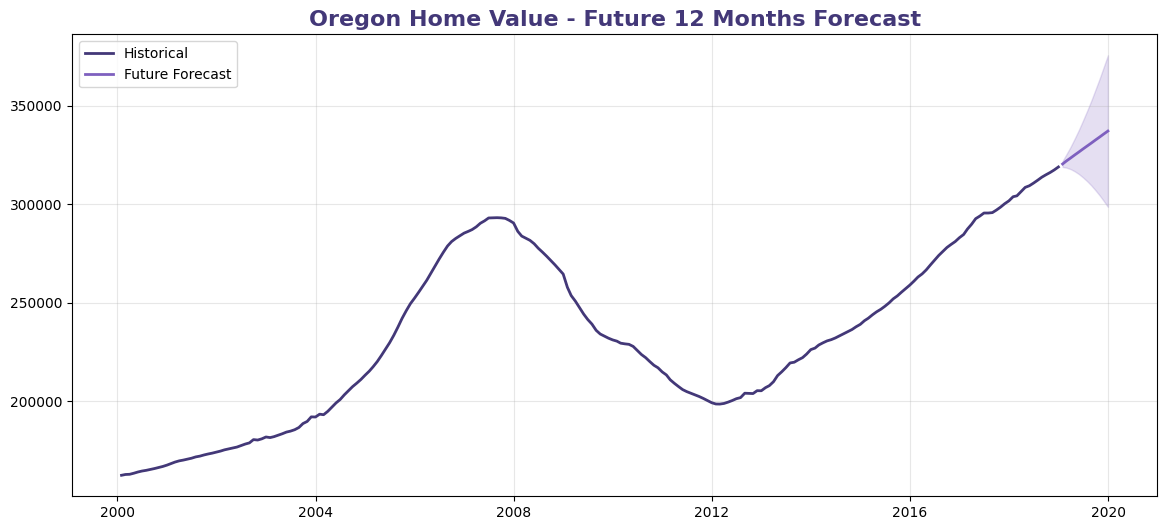

In [206]:
plt.figure(figsize=(14,6))


plt.plot(
    oregon_ts,
    label="Historical",
    color=MY_DARK_PURPLE,
    linewidth=2
)


plt.plot(
    future_df["mean"],
    label="Future Forecast",
    color=MY_MED_PURPLE,
    linewidth=2
)


plt.fill_between(
    future_df.index,
    future_df["mean_ci_lower"],
    future_df["mean_ci_upper"],
    color=MY_MED_PURPLE,
    alpha=.2
)


plt.title(
    "Oregon Home Value - Future 12 Months Forecast",
    fontsize=16,
    color=MY_DARK_PURPLE,
    fontweight="bold"
)


plt.grid(alpha=.3)
plt.legend()
plt.show()

#**Forecast Summary**

In [207]:
final_prediction = future_df["mean"].iloc[-1]


percent_change = (
    (final_prediction - oregon_ts.iloc[-1])
    /
    oregon_ts.iloc[-1]
)*100


print(
    "Predicted final month value:",
    round(final_prediction,2)
)


print(
    "12 Month Percent Change:",
    round(percent_change,2),
    "%"
)

Predicted final month value: 337253.12
12 Month Percent Change: 5.71 %


### **Forecast Key Findings & Insights**

* **Final Month Predicted Value:** The model predicts that the home value will reach **337,253.12** by the end of the 12-month forecast period.
* **12-Month Growth Rate:** There is a predicted price increase of **5.71%** over the next 12 months compared to the last actual observed value in the dataset.
* **Interpretation:** This confirms that the **Auto ARIMA(0,2,0)** model projects a steady, upward growth trend for the housing market, continuing its historical momentum without seasonal fluctuations.